John Laffey
- PID: 5681808
- Email: jo407341@ucf.edu
- Date: 03/02/2026
- Week 7 Coding Assignment

In [34]:
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd



## Part 1

In [35]:
import os

treasury_ind = "^TNX"
sp500_ind = "^GSPC"

sp500_cache = "sp500_cache.csv"
treasury_cache = "treasury_cache.csv"

if os.path.exists(sp500_cache) and os.path.exists(treasury_cache):
    sp500: pd.DataFrame = pd.read_csv(sp500_cache, index_col=0, parse_dates=True, header=[0, 1])
    treasury: pd.DataFrame = pd.read_csv(treasury_cache, index_col=0, parse_dates=True, header=[0, 1])
else:
    sp500 = yf.download(sp500_ind, start="2016-01-01", end="2026-01-01")
    treasury = yf.download(treasury_ind, start="2016-01-01", end="2026-01-01")
    sp500.to_csv(sp500_cache)
    treasury.to_csv(treasury_cache)

/home/amos-burton/code/school/.venv/lib/python3.13/site-packages/yfinance/scrapers/history.py:169: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/home/amos-burton/code/school/.venv/lib/python3.13/site-packages/yfinance/scrapers/history.py:169: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


In [36]:
# SP500
print(sp500.columns) # type: ignore

MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])


In [37]:
print(treasury.columns) # type: ignore

MultiIndex([( 'Close', '^TNX'),
            (  'High', '^TNX'),
            (   'Low', '^TNX'),
            (  'Open', '^TNX'),
            ('Volume', '^TNX')],
           names=['Price', 'Ticker'])


In [38]:
# Step 2 - Preprocessing Data
df_merged = sp500['Close'].merge(treasury['Close'], left_index=True, right_index=True) # type: ignore
df_merged.columns = ['sp500_close', 'treasury_yield']
df_merged = df_merged.dropna()
# print(df_merged)

In [39]:
# Step 3 & 4

X = df_merged[['treasury_yield']]  # Independent variable
y = df_merged['sp500_close']       # Dependent variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Step 5, 6, 7
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")
print(f"Model Coefficient: {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Mean Absolute Error: 867.29
R-squared Score: 0.39
Model Coefficient: 696.64
Model Intercept: 1904.29


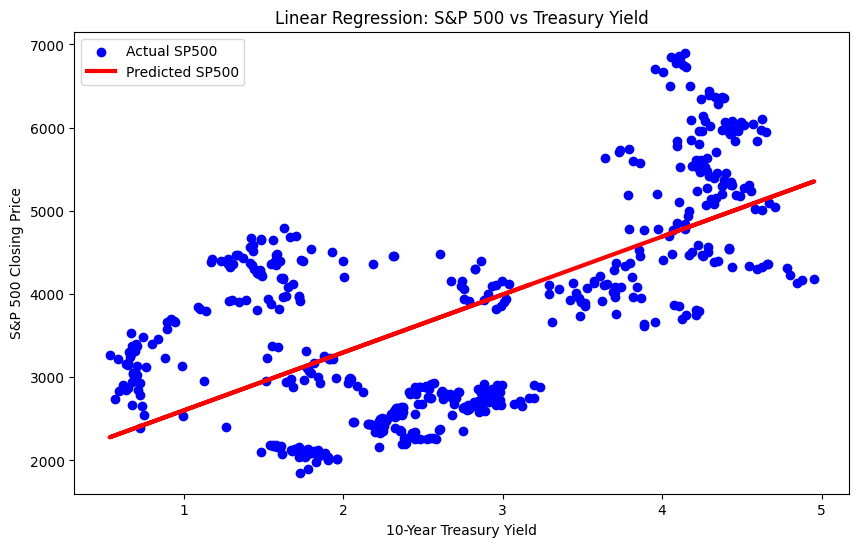

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual SP500')
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Predicted SP500')
plt.title('Linear Regression: S&P 500 vs Treasury Yield')
plt.xlabel('10-Year Treasury Yield')
plt.ylabel('S&P 500 Closing Price')
plt.legend()
plt.show()

## Part 2

In [42]:
# Step 2 - Feature Engineering
sp500_feat = sp500['Close'].copy() # type: ignore
sp500_feat.columns = ['Close'] # type: ignore

sp500_feat['Daily_Return'] = sp500_feat['Close'].pct_change()
sp500_feat['50_MA'] = sp500_feat['Close'].rolling(window=50).mean()
sp500_feat['Volatility'] = sp500_feat['Daily_Return'].rolling(window=20).std()
sp500_feat['Market_Direction'] = (sp500_feat['Close'] > sp500_feat['50_MA']).astype(int)

In [43]:
# Step 3, 4
final_df = sp500_feat.merge(treasury['Close'], left_index=True, right_index=True) # type: ignore
final_df.columns = ['Close', 'Daily_Return', '50_MA', 'Volatility', 'Market_Direction', 'Treasury_Yield']

final_df = final_df.dropna()
# Define x, y
X_log = final_df[['Close', 'Treasury_Yield', '50_MA', 'Volatility']]
y_log = final_df['Market_Direction']

# Train-Test Split 80/20
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Standardize the features for LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_l)
X_test_scaled = scaler.transform(X_test_l)

Model Accuracy: 0.91

Classification Report:


              precision    recall  f1-score   support

           0       0.92      0.71      0.80       124
           1       0.91      0.98      0.94       369

    accuracy                           0.91       493
   macro avg       0.91      0.84      0.87       493
weighted avg       0.91      0.91      0.91       493



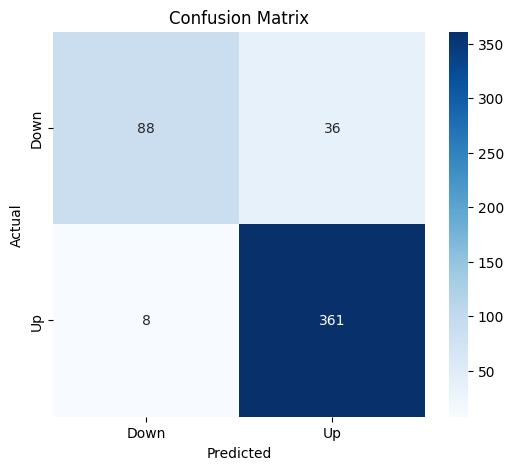

In [44]:
# Steps 5, 6, 7, 8

# Train Model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_l)

# Predictions
y_pred_l = log_model.predict(X_test_scaled)

# Evaluate
print(f"Model Accuracy: {accuracy_score(y_test_l, y_pred_l):.2f}")
print("\nClassification Report:")
print(classification_report(y_test_l, y_pred_l))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_l, y_pred_l)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()